# Minimax Algorithm

Minimax is a **decision-making algorithm** for two-player, zero-sum games — where one player's gain is exactly the other's loss. It powers game-playing AIs for Chess, Tic-Tac-Toe, Checkers, and more.

## The core idea

Two players alternate turns:
- **Maximizer** — wants the highest possible score (e.g. the AI)
- **Minimizer** — wants the lowest possible score (e.g. the opponent)

Minimax assumes **both players play perfectly**. The maximizer asks: *"If I make this move, what is the best my opponent can do against me?"* and picks the move that maximizes the worst-case outcome.

## How it works

1. Build a **game tree** — nodes are game states, edges are moves
2. Score **leaf nodes** with a utility function (e.g. +10 win, −10 loss, 0 draw)
3. **Propagate values upward**: MAX nodes take the max of their children, MIN nodes take the min
4. The value at the root is the best guaranteed outcome; the child that produced it is the best move

## Pseudocode

```
function minimax(node, depth, maximizingPlayer) is
    if depth = 0 or node is terminal then
        return heuristic value of node
    if maximizingPlayer then
        value := −∞
        for each child of node do
            value := max(value, minimax(child, depth − 1, FALSE))
        return value
    else
        value := +∞
        for each child of node do
            value := min(value, minimax(child, depth − 1, TRUE))
        return value
```

### Step 1: Implement minimax

The function traverses a **binary game tree** recursively, alternating between MAX and MIN layers.

**Parameters:**
- `depth` — how deep we currently are (0 = root)
- `nodeIndex` — position in the flattened `values` array; children of node `i` are at `2i` and `2i+1`
- `isMaximizingPlayer` — `True` on the maximizer's turn, `False` on the minimizer's
- `values` — scores at the leaf nodes
- `maxDepth` — depth where leaves live; triggers the base case
- `counter` — optional `[0]` list to count nodes evaluated (measures search effort)

In [1]:
def minimax(depth, nodeIndex, isMaximizingPlayer, values, maxDepth, counter=None):
    if counter is not None:
        counter[0] += 1          # count every node we visit

    # Base case: reached a leaf node
    if depth == maxDepth:
        return values[nodeIndex]

    if isMaximizingPlayer:
        best = float('-inf')
        for i in range(2):       # two children: left (2*idx) and right (2*idx+1)
            val = minimax(depth + 1, nodeIndex * 2 + i, False, values, maxDepth, counter)
            best = max(best, val)
        return best
    else:
        best = float('inf')
        for i in range(2):
            val = minimax(depth + 1, nodeIndex * 2 + i, True, values, maxDepth, counter)
            best = min(best, val)
        return best

### Step 2: Run the algorithm

The 8 leaf values `[3, 5, 2, 9, 12, 5, 23, 15]` form a complete binary tree of depth 3.

```
Depth 0 (MAX):                 [  ?  ]
Depth 1 (MIN):         [  ?  ]         [  ?  ]
Depth 2 (MAX):     [  ?  ] [  ?  ]  [  ?  ] [  ?  ]
Depth 3 (leaves):   3    5   2    9   12   5  23   15
```

Minimax propagates values upward:
- Depth 2 MAX: `max(3,5)=5`,  `max(2,9)=9`,  `max(12,5)=12`,  `max(23,15)=23`
- Depth 1 MIN: `min(5,9)=5`,  `min(12,23)=12`
- Depth 0 MAX: `max(5,12)=12`  ← optimal value for the maximizer

In [2]:
import math

values   = [3, 5, 2, 9, 12, 5, 23, 15]
maxDepth = math.floor(math.log2(len(values)))

counter = [0]
optimal = minimax(0, 0, True, values, maxDepth, counter)

print(f"Tree depth:    {maxDepth}")
print(f"Optimal value: {optimal}")
print(f"Nodes visited: {counter[0]}  (all {2**(maxDepth+1)-1} nodes in the complete tree)")

Tree depth:    3
Optimal value: 12
Nodes visited: 15  (all 15 nodes in the complete tree)


### Visualizing the tree

The tree below shows the propagated value at every node.
- **Green circles** — MAX nodes (maximizer's turn)
- **Blue squares** — MIN nodes (minimizer's turn)

Values flow from the leaves up to the root. Notice that the root ends up with `12` — the maximizer's best guaranteed outcome assuming perfect play from both sides.

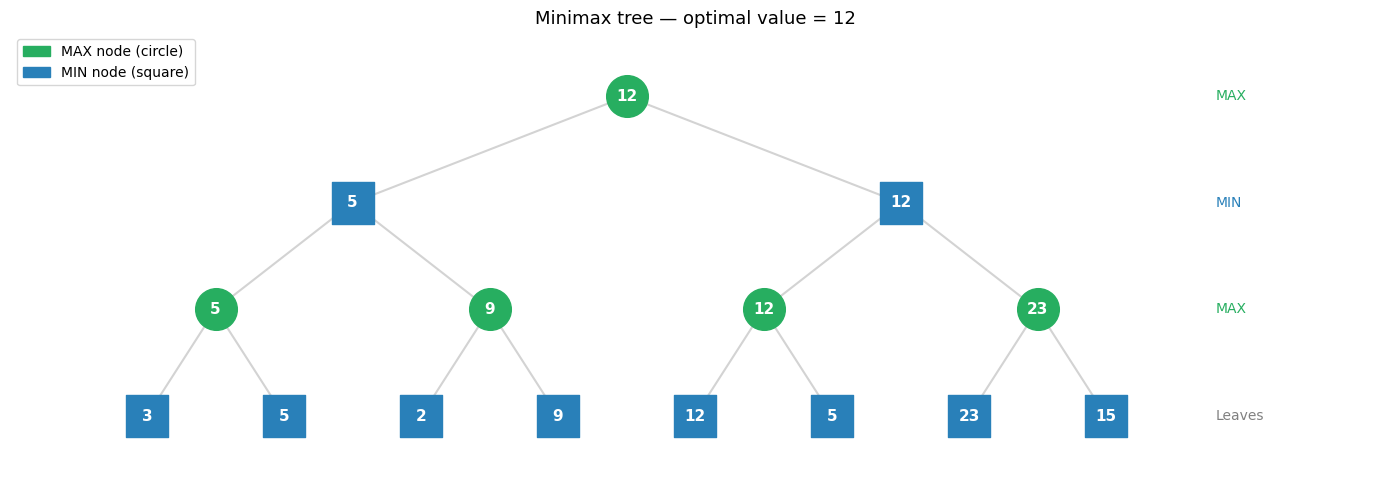

In [3]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def visualize_minimax_tree(values, maxDepth, title='Minimax tree'):
    n_leaves = 2 ** maxDepth

    # Compute minimax value for every node
    tree = {}
    def fill(depth, idx):
        if depth == maxDepth:
            tree[(depth, idx)] = values[idx]
        else:
            left  = fill(depth + 1, idx * 2)
            right = fill(depth + 1, idx * 2 + 1)
            tree[(depth, idx)] = max(left, right) if depth % 2 == 0 else min(left, right)
        return tree[(depth, idx)]
    fill(0, 0)

    def pos(depth, idx):
        width = n_leaves / (2 ** depth)
        return idx * width + width / 2, maxDepth - depth

    fig, ax = plt.subplots(figsize=(14, 5))

    # Edges
    for depth in range(maxDepth):
        for idx in range(2 ** depth):
            px, py = pos(depth, idx)
            for child in range(2):
                cx, cy = pos(depth + 1, idx * 2 + child)
                ax.plot([px, cx], [py, cy], color='lightgray', linewidth=1.5, zorder=1)

    # Nodes
    for (depth, idx), val in tree.items():
        x, y   = pos(depth, idx)
        is_max = (depth % 2 == 0)
        color  = '#27ae60' if is_max else '#2980b9'
        marker = 'o' if is_max else 's'
        ax.scatter(x, y, s=900, color=color, zorder=3, marker=marker)
        ax.text(x, y, str(val), ha='center', va='center',
                fontsize=11, fontweight='bold', color='white', zorder=4)

    # Level labels
    for depth in range(maxDepth + 1):
        _, y   = pos(depth, 0)
        is_max = depth % 2 == 0
        label  = 'Leaves' if depth == maxDepth else ('MAX' if is_max else 'MIN')
        color  = 'gray' if depth == maxDepth else ('#27ae60' if is_max else '#2980b9')
        ax.text(n_leaves + 0.3, y, label, va='center', fontsize=10, color=color)

    ax.set_xlim(-0.5, n_leaves + 1.5)
    ax.set_ylim(-0.6, maxDepth + 0.6)
    ax.axis('off')
    ax.set_title(title, fontsize=13)

    max_p = mpatches.Patch(color='#27ae60', label='MAX node (circle)')
    min_p = mpatches.Patch(color='#2980b9', label='MIN node (square)')
    ax.legend(handles=[max_p, min_p], loc='upper left', fontsize=10)
    plt.tight_layout()
    plt.show()

visualize_minimax_tree(values, maxDepth, title=f'Minimax tree — optimal value = {optimal}')

### Tic-Tac-Toe: a realistic example

Tic-Tac-Toe is a classic minimax showcase. The game tree is small enough to search exhaustively (~255,168 possible games), so minimax can play **perfectly** — it never loses.

**Scoring convention (from X's perspective):**
| Outcome | Score |
|---------|-------|
| X wins  | +10   |
| O wins  | −10   |
| Draw / ongoing | 0 |

`find_best_move` wraps minimax to return the **board position** of X's optimal next move, not just the score.

In [4]:
def print_board(board):
    for row in board:
        print(' | '.join(cell if cell != '_' else '.' for cell in row))
    print()

def evaluate(board):
    lines = (
        board[0], board[1], board[2],                              # rows
        [board[r][0] for r in range(3)],                           # col 0
        [board[r][1] for r in range(3)],                           # col 1
        [board[r][2] for r in range(3)],                           # col 2
        [board[i][i]   for i in range(3)],                         # diagonal
        [board[i][2-i] for i in range(3)],                         # anti-diagonal
    )
    for line in lines:
        if line == ['X', 'X', 'X']:
            return 10
        if line == ['O', 'O', 'O']:
            return -10
    return 0

def is_moves_left(board):
    return any('_' in row for row in board)

def minimax_ttt(board, depth, isMax):
    score = evaluate(board)
    if score != 0 or not is_moves_left(board):
        return score

    if isMax:
        best = float('-inf')
        for i in range(3):
            for j in range(3):
                if board[i][j] == '_':
                    board[i][j] = 'X'
                    best = max(best, minimax_ttt(board, depth + 1, False))
                    board[i][j] = '_'
        return best
    else:
        best = float('inf')
        for i in range(3):
            for j in range(3):
                if board[i][j] == '_':
                    board[i][j] = 'O'
                    best = min(best, minimax_ttt(board, depth + 1, True))
                    board[i][j] = '_'
        return best

def find_best_move(board):
    """Return (row, col) of the optimal move for X."""
    best_val  = float('-inf')
    best_move = (-1, -1)
    for i in range(3):
        for j in range(3):
            if board[i][j] == '_':
                board[i][j] = 'X'
                move_val = minimax_ttt(board, 0, False)
                board[i][j] = '_'
                if move_val > best_val:
                    best_val  = move_val
                    best_move = (i, j)
    return best_move

# Demo: X must win or draw — find the best move
board = [
    ['X', 'O', 'X'],
    ['O', 'O', '_'],
    ['_', 'X', '_']
]

print('Board before X plays:')
print_board(board)

row, col = find_best_move(board)
board[row][col] = 'X'
print(f"Minimax plays X at row {row}, col {col}:")
print_board(board)

result = evaluate(board)
if result == 10:
    print('X wins!')
elif result == -10:
    print('O wins!')
else:
    print('Draw or game continues...')

Board before X plays:
X | O | X
O | O | .
. | X | .

Minimax plays X at row 1, col 2:
X | O | X
O | O | X
. | X | .

Draw or game continues...


## Alpha-beta pruning

Alpha-beta pruning is an optimization of minimax that **skips branches that cannot affect the final result**, dramatically reducing the number of nodes evaluated — without changing the answer.

### The key insight

While searching, we maintain two bounds:
- **α (alpha)** — the best value the **maximizer** is already guaranteed (initialized to −∞)
- **β (beta)** — the best value the **minimizer** is already guaranteed (initialized to +∞)

**Pruning rule:**
- If a MAX node finds `value ≥ β`: the minimizer above would never choose this path → **prune** remaining children (β-cutoff)
- If a MIN node finds `value ≤ α`: the maximizer above would never choose this path → **prune** remaining children (α-cutoff)

In the best case (moves ordered optimally), alpha-beta reduces the effective branching factor from `b` to `√b`, allowing minimax to search **twice as deep** in the same time. In practice it typically cuts 40–60% of nodes.

### Pseudocode

```
function alphabeta(node, depth, α, β, maximizingPlayer) is
    if depth = 0 or node is terminal then
        return heuristic value of node
    if maximizingPlayer then
        value := −∞
        for each child of node do
            value := max(value, alphabeta(child, depth−1, α, β, FALSE))
            α := max(α, value)
            if value ≥ β then break   (* β cutoff — minimizer won't allow this *)
        return value
    else
        value := +∞
        for each child of node do
            value := min(value, alphabeta(child, depth−1, α, β, TRUE))
            β := min(β, value)
            if value ≤ α then break   (* α cutoff — maximizer won't allow this *)
        return value
```

In [5]:
def alphabeta(depth, nodeIndex, isMaximizingPlayer, values, maxDepth,
              alpha=float('-inf'), beta=float('inf'), counter=None, visited=None):
    if counter is not None:
        counter[0] += 1
    if visited is not None:
        visited.add((depth, nodeIndex))

    if depth == maxDepth:
        return values[nodeIndex]

    if isMaximizingPlayer:
        value = float('-inf')
        for i in range(2):
            value = max(value, alphabeta(depth + 1, nodeIndex * 2 + i, False,
                                         values, maxDepth, alpha, beta, counter, visited))
            alpha = max(alpha, value)
            if value >= beta:
                break           # β cutoff
        return value
    else:
        value = float('inf')
        for i in range(2):
            value = min(value, alphabeta(depth + 1, nodeIndex * 2 + i, True,
                                         values, maxDepth, alpha, beta, counter, visited))
            beta = min(beta, value)
            if value <= alpha:
                break           # α cutoff
        return value


mm_counter = [0]
ab_counter = [0]
ab_visited = set()

mm_result = minimax(0, 0, True, values, maxDepth, mm_counter)
ab_result = alphabeta(0, 0, True, values, maxDepth, counter=ab_counter, visited=ab_visited)

print(f'Same result?       {mm_result == ab_result}  (both return {mm_result})')
print(f'Minimax nodes:     {mm_counter[0]}')
print(f'Alpha-beta nodes:  {ab_counter[0]}')
print(f'Nodes pruned:      {mm_counter[0] - ab_counter[0]}  ({100*(1 - ab_counter[0]/mm_counter[0]):.0f}% reduction)')

Same result?       True  (both return 12)
Minimax nodes:     15
Alpha-beta nodes:  14
Nodes pruned:      1  (7% reduction)


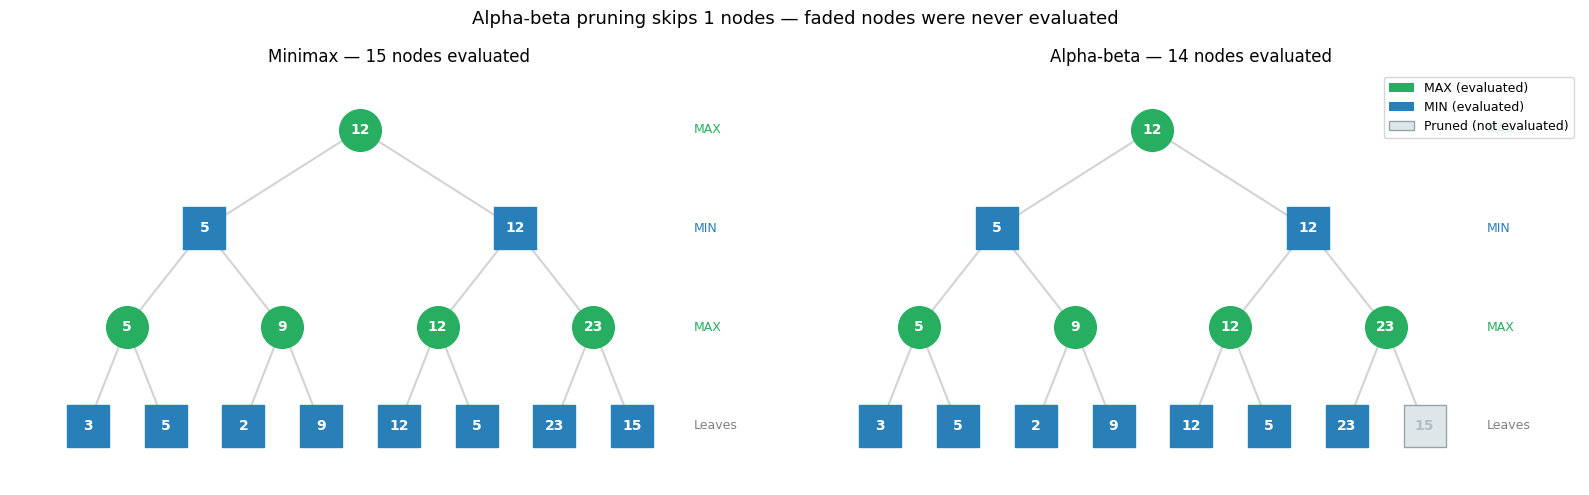

In [6]:
def visualize_pruning(values, maxDepth, ab_visited):
    n_leaves  = 2 ** maxDepth
    all_nodes = {(d, i) for d in range(maxDepth + 1) for i in range(2 ** d)}

    # Compute node values
    tree = {}
    def fill(depth, idx):
        if depth == maxDepth:
            tree[(depth, idx)] = values[idx]
        else:
            l = fill(depth + 1, idx * 2)
            r = fill(depth + 1, idx * 2 + 1)
            tree[(depth, idx)] = max(l, r) if depth % 2 == 0 else min(l, r)
        return tree[(depth, idx)]
    fill(0, 0)

    def pos(depth, idx):
        width = n_leaves / (2 ** depth)
        return idx * width + width / 2, maxDepth - depth

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    for ax, visited, label in [
        (axes[0], all_nodes, f'Minimax — {len(all_nodes)} nodes evaluated'),
        (axes[1], ab_visited, f'Alpha-beta — {len(ab_visited)} nodes evaluated'),
    ]:
        # Edges
        for depth in range(maxDepth):
            for idx in range(2 ** depth):
                px, py = pos(depth, idx)
                for child in range(2):
                    cx, cy = pos(depth + 1, idx * 2 + child)
                    ax.plot([px, cx], [py, cy], color='lightgray', linewidth=1.5, zorder=1)

        # Nodes
        for (depth, idx), val in tree.items():
            x, y         = pos(depth, idx)
            is_max       = (depth % 2 == 0)
            was_visited  = (depth, idx) in visited
            color        = ('#27ae60' if is_max else '#2980b9') if was_visited else '#dfe6e9'
            text_color   = 'white' if was_visited else '#b2bec3'
            marker       = 'o' if is_max else 's'
            ax.scatter(x, y, s=900, color=color, zorder=3, marker=marker,
                       edgecolors='#95a5a6' if not was_visited else color, linewidths=1)
            ax.text(x, y, str(val), ha='center', va='center',
                    fontsize=10, fontweight='bold', color=text_color, zorder=4)

        # Level labels
        for depth in range(maxDepth + 1):
            _, y   = pos(depth, 0)
            is_max = depth % 2 == 0
            label2 = 'Leaves' if depth == maxDepth else ('MAX' if is_max else 'MIN')
            color  = 'gray' if depth == maxDepth else ('#27ae60' if is_max else '#2980b9')
            ax.text(n_leaves + 0.3, y, label2, va='center', fontsize=9, color=color)

        ax.set_xlim(-0.5, n_leaves + 1.5)
        ax.set_ylim(-0.6, maxDepth + 0.6)
        ax.axis('off')
        ax.set_title(label, fontsize=12)

    pruned = len(all_nodes) - len(ab_visited)
    plt.suptitle(
        f'Alpha-beta pruning skips {pruned} nodes — faded nodes were never evaluated',
        fontsize=13
    )
    max_p   = mpatches.Patch(facecolor='#27ae60', label='MAX (evaluated)')
    min_p   = mpatches.Patch(facecolor='#2980b9', label='MIN (evaluated)')
    prune_p = mpatches.Patch(facecolor='#dfe6e9', edgecolor='#95a5a6', label='Pruned (not evaluated)')
    axes[1].legend(handles=[max_p, min_p, prune_p], loc='upper right', fontsize=9)
    plt.tight_layout()
    plt.show()

visualize_pruning(values, maxDepth, ab_visited)